This notebook contains experiments evaluating an LSTM (Long Short-Term Memory) model for multi-class text classification on a news dataset. Each article’s title and description are combined into a single text input, preprocessed by lowercasing, URL removal, and whitespace normalization. The notebook compares three types of text representations — TF-IDF, Word2Vec (Skip-gram), and GloVe embeddings — to assess their impact on LSTM performance. The LSTM model is trained on an 80/20 stratified train-validation split, and results are reported using accuracy, precision, recall, and F1-score. TF-IDF + LSTM achieved the best performance (~90.6% accuracy), while Word2Vec and GloVe embeddings collapsed to predicting a single class, highlighting the suitability of TF-IDF for short, keyword-driven text classification tasks.

In [2]:
!pip install gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 67.4 MB/s eta 0:00:00:00:0100:01


In [ ]:
# import the  libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

from gensim.models import Word2Vec

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓  libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")

✓  libraries imported successfully
TensorFlow version: 2.19.0


In [4]:

tf.config.list_physical_devices('GPU')


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Set seed for producibility


In [5]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [6]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Load datasets

In [7]:
DATA_DIR = "/content/drive/MyDrive/data"

train_path = os.path.join(DATA_DIR, "train.csv")
test_path  = os.path.join(DATA_DIR, "test.csv")

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print(train_df.columns)


Train shape: (120000, 3)
Test shape: (7600, 3)
Index(['Class Index', 'Title', 'Description'], dtype='object')


  Preprocess and Split Data

In [8]:

# Normalize column names
train_df.columns = [c.lower().strip() for c in train_df.columns]
test_df.columns = [c.lower().strip() for c in test_df.columns]

# Combine title + description
for df in [train_df, test_df]:
    df["title"] = df["title"].fillna("")
    df["description"] = df["description"].fillna("")
    df["text"] = df["title"] + " " + df["description"]

# Text cleaning
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["text"] = train_df["text"].apply(clean_text)
test_df["text"] = test_df["text"].apply(clean_text)

# Label encoding
train_df["label"] = train_df["class index"] - 1

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    train_df["text"],
    train_df["label"],
    test_size=0.2,
    stratify=train_df["label"],
    random_state=42
)

print("Train samples:", len(X_train))
print("Validation samples:", len(X_val))
print(f"Number of classes: {train_df['label'].nunique()}")

Train samples: 96000
Validation samples: 24000
Number of classes: 4


Tokenization & Padding

In [9]:
MAX_VOCAB = 30000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding="post")

vocab_size = len(tokenizer.word_index) + 1
num_classes = len(train_df["label"].unique())

print(f"Vocabulary size: {vocab_size:,}")
print(f"  Number of classes: {num_classes}")

Vocabulary size: 64,588
  Number of classes: 4


LSTM Model

In [10]:
def build_lstm(embedding_matrix=None, embedding_dim=100):
    model = Sequential()

    if embedding_matrix is not None:
        model.add(Embedding(
            input_dim=embedding_matrix.shape[0],
            output_dim=embedding_matrix.shape[1],
            weights=[embedding_matrix],
            input_length=MAX_LEN,
            trainable=False
        ))
    else:
        model.add(Embedding(vocab_size, embedding_dim, input_length=MAX_LEN))

    model.add(LSTM(128))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

print(" LSTM model builder ready")

 LSTM model builder ready


TF-IDF - Vectorize, Build & Train

In [11]:
# Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_val_tfidf = tfidf.transform(X_val).toarray()

# Build model
model_tfidf = Sequential([
    Dense(256, activation="relu", input_shape=(X_train_tfidf.shape[1],)),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

model_tfidf.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Train
history_tfidf = model_tfidf.fit(
    X_train_tfidf, y_train,
    validation_data=(X_val_tfidf, y_val),
    epochs=10,
    batch_size=128
)

print("\n TF-IDF model training complete")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8427 - loss: 0.5820 - val_accuracy: 0.9107 - val_loss: 0.2602
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9185 - loss: 0.2389 - val_accuracy: 0.9117 - val_loss: 0.2539
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9282 - loss: 0.2053 - val_accuracy: 0.9109 - val_loss: 0.2563
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9372 - loss: 0.1791 - val_accuracy: 0.9097 - val_loss: 0.2633
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9461 - loss: 0.1553 - val_accuracy: 0.9102 - val_loss: 0.2723
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9551 - loss: 0.1311 - val_accuracy: 0.9089 - val_loss: 0.2858
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9642 - loss: 0.1085 - val_accuracy: 0.9090 - val_loss: 0.3015
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9721 - loss: 0.0879 - val_accuracy: 0.

 WORD2VEC + LSTM

In [12]:
# Train Word2Vec
sentences = [text.split() for text in X_train]
w2v = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    sg=1,
    min_count=2,
    workers=4,
    seed=42
)

# Build embedding matrix
embedding_matrix_w2v = np.zeros((vocab_size, 100))
words_found = 0
for word, i in tokenizer.word_index.items():
    if i < vocab_size and word in w2v.wv:
        embedding_matrix_w2v[i] = w2v.wv[word]
        words_found += 1

print(f"✓ Word2Vec words found: {words_found:,} / {vocab_size:,} ({100*words_found/vocab_size:.2f}%)")

# Build and train LSTM - TRAINABLE EMBEDDINGS
model_w2v = Sequential()
model_w2v.add(Embedding(
    input_dim=vocab_size,
    output_dim=100,
    weights=[embedding_matrix_w2v],
    input_length=MAX_LEN,
    trainable=True  # CHANGED: Allow fine-tuning
))
model_w2v.add(LSTM(128))
model_w2v.add(Dropout(0.3))
model_w2v.add(Dense(num_classes, activation="softmax"))

model_w2v.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_w2v = model_w2v.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=20,
    batch_size=128,
    verbose=1
)

print("\n Word2Vec + LSTM training complete")

✓ Word2Vec words found: 37,627 / 64,588 (58.26%)
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.2485 - loss: 1.3868 - val_accuracy: 0.2500 - val_loss: 1.3864
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.2471 - loss: 1.3867 - val_accuracy: 0.2500 - val_loss: 1.3864
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.2459 - loss: 1.3867 - val_accuracy: 0.2500 - val_loss: 1.3864
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.2461 - loss: 1.3866 - val_accuracy: 0.2500 - val_loss: 1.3864
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.2472 - loss: 1.3866 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.2480 - loss: 1.3865 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.2468 - loss: 1.3865 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.2456 - loss: 1.3865 - val_accurac

GLOVE + LSTM

In [14]:
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip
print(" GloVe downloaded")

 GloVe downloaded


 Build Matrix & Train LSTM

In [18]:
# Load GloVe
glove_path = "glove.6B.100d.txt"
glove = {}
with open(glove_path, encoding="utf8") as f:
    for line in f:
        values = line.split()
        glove[values[0]] = np.array(values[1:], dtype="float32")

# Build embedding matrix
embedding_matrix_glove = np.zeros((vocab_size, 100))
words_found = 0
for word, i in tokenizer.word_index.items():
    if i < vocab_size and word in glove:
        embedding_matrix_glove[i] = glove[word]
        words_found += 1

print(f" GloVe words found: {words_found:,} / {vocab_size:,}")

# Build and train LSTM - TRAINABLE EMBEDDINGS
model_glove = Sequential()
model_glove.add(Embedding(
    input_dim=vocab_size,
    output_dim=100,
    weights=[embedding_matrix_glove],
    input_length=MAX_LEN,
    trainable=True  # CHANGED: Allow fine-tuning
))
model_glove.add(LSTM(128))
model_glove.add(Dropout(0.3))
model_glove.add(Dense(num_classes, activation="softmax"))

model_glove.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_glove = model_glove.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=20,
    batch_size=128,
    verbose=1
)

print("\n  GloVe + LSTM training complete")

 GloVe words found: 53,267 / 64,588
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.2499 - loss: 1.3868 - val_accuracy: 0.2500 - val_loss: 1.3864
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.2475 - loss: 1.3867 - val_accuracy: 0.2500 - val_loss: 1.3864
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.2512 - loss: 1.3866 - val_accuracy: 0.2500 - val_loss: 1.3864
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.2464 - loss: 1.3866 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.2484 - loss: 1.3865 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.2480 - loss: 1.3865 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.2474 - loss: 1.3865 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.2443 - loss: 1.3865 - val_accurac

EVALUATION

In [19]:
# Define Evaluation Function
def evaluate(model, X, y, name):
    preds = np.argmax(model.predict(X), axis=1)

    print(f"\n{'='*60}")
    print(f"{name} CLASSIFICATION REPORT")
    print(f"{'='*60}")
    print(classification_report(y, preds))

    cm = confusion_matrix(y, preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

print(" Evaluation function ready")

 Evaluation function ready


Evaluate All Models

750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

TF-IDF CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      6000
           1       0.96      0.96      0.96      6000
           2       0.87      0.89      0.88      6000
           3       0.89      0.88      0.88      6000

    accuracy                           0.91     24000
   macro avg       0.91      0.91      0.91     24000
weighted avg       0.91      0.91      0.91     24000



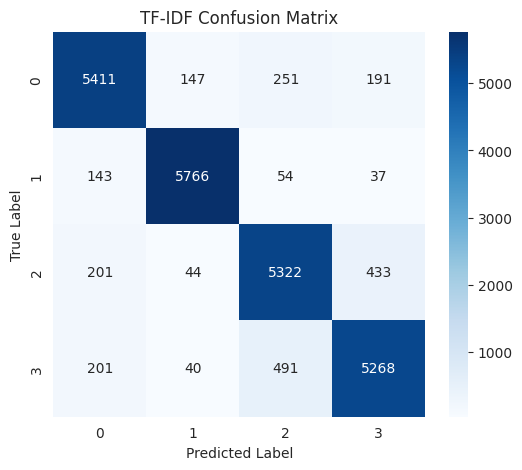

750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

Word2Vec CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.25      1.00      0.40      6000
           1       0.00      0.00      0.00      6000
           2       0.00      0.00      0.00      6000
           3       0.00      0.00      0.00      6000

    accuracy                           0.25     24000
   macro avg       0.06      0.25      0.10     24000
weighted avg       0.06      0.25      0.10     24000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


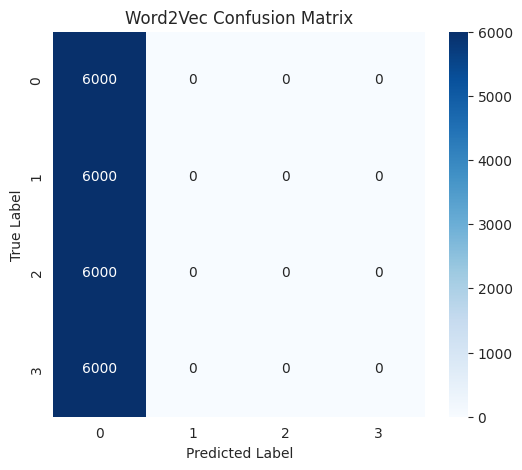

750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

GloVe CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      6000
           1       0.25      1.00      0.40      6000
           2       0.00      0.00      0.00      6000
           3       0.00      0.00      0.00      6000

    accuracy                           0.25     24000
   macro avg       0.06      0.25      0.10     24000
weighted avg       0.06      0.25      0.10     24000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


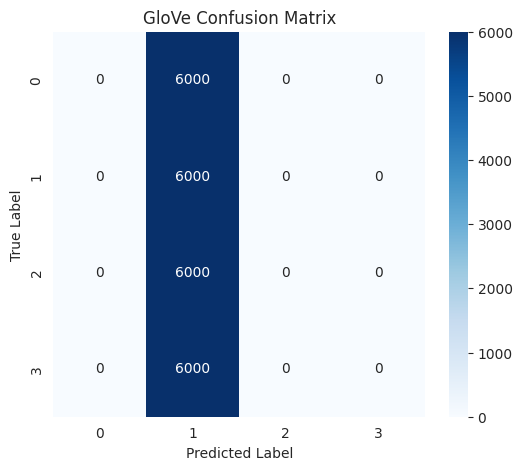

In [20]:
evaluate(model_tfidf, X_val_tfidf, y_val, "TF-IDF")
evaluate(model_w2v, X_val_pad, y_val, "Word2Vec")
evaluate(model_glove, X_val_pad, y_val, "GloVe")

Compare Results

750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
 29/750 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

LSTM MODEL COMPARISON
   Model  Accuracy  Precision   Recall  F1-Score
  TF-IDF  0.906333   0.906705 0.906333  0.906372
Word2Vec  0.250000   0.062500 0.250000  0.100000
   GloVe  0.250000   0.062500 0.250000  0.100000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


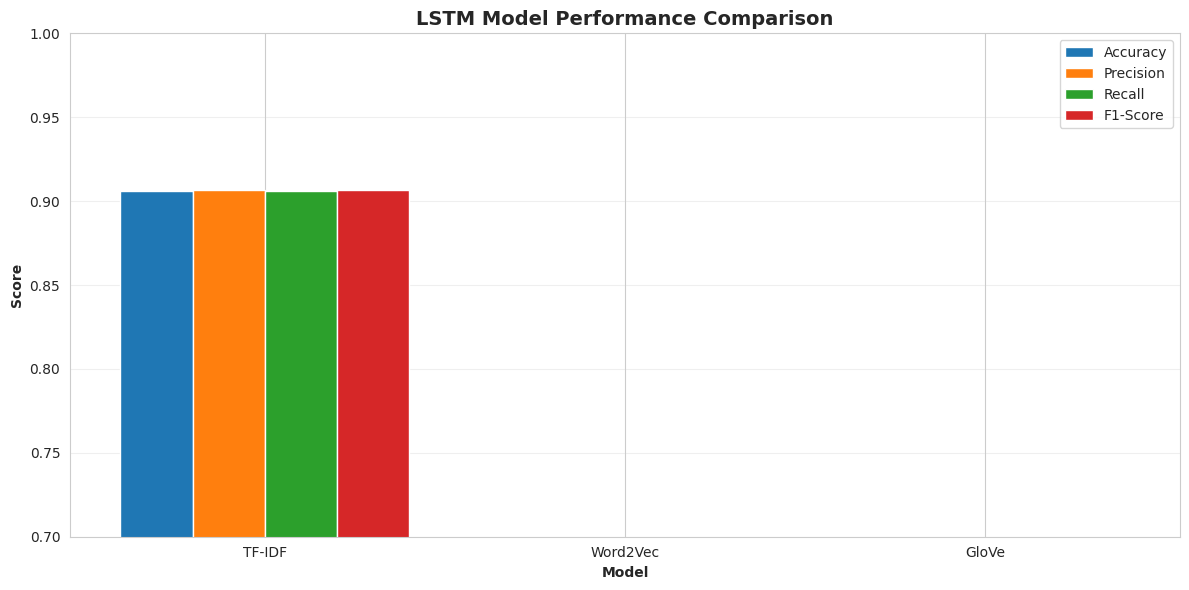

In [53]:
# Collect results
results = []

def save_results(name, model, X, y):
    preds = np.argmax(model.predict(X), axis=1)
    report = classification_report(y, preds, output_dict=True)
    results.append({
        'Model': name,
        'Accuracy': report['accuracy'],
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1-Score': report['weighted avg']['f1-score']
    })

save_results("TF-IDF", model_tfidf, X_val_tfidf, y_val)
save_results("Word2Vec", model_w2v, X_val_pad, y_val)
save_results("GloVe", model_glove, X_val_pad, y_val)

results_df = pd.DataFrame(results)
print("\n" + "="*70)
print("LSTM MODEL COMPARISON")
print("="*70)
print(results_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df))
width = 0.2

for i, metric in enumerate(metrics):
    ax.bar(x + i*width, results_df[metric], width, label=metric)

ax.set_xlabel('Model', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('LSTM Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Model'])
ax.legend()
ax.set_ylim([0.7, 1.0])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()